In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Install thrember and its dependencies using the local pyproject.toml/setup.cfg
!pip install -e /content/drive/MyDrive/EMBER2024

Obtaining file:///content/drive/MyDrive/EMBER2024
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thrember (pyproject.toml) ... done
  Created wheel for thrember: filename=thrember-0.1.0-0.editable-py3-none-any.whl size=4202 sha256=01c50c8be4264b02c78a41d2fb9f331f225fd3e16e89db7b1a138a2d1e708522
  Stored in directory: /tmp/pip-ephem-wheel-cache-rz4ml3b2/wheels/f4/6a/24/ad2479de46c3aa5f4936e90692bb90c086631dd2ca26d46678
Successfully built thrember
  Attempting uninstall: thrember
    Found existing installation: thrember 0.1.0
    Uninstalling thrember-0.1.0:
      Successfully uninstalled thrember-0.1.0


In [3]:
import sys
import os
import datetime
# Add the src directory to the python path
src_path = "/content/drive/MyDrive/EMBER2024/src"
if src_path not in sys.path:
    sys.path.append(src_path)

import thrember
print("thrember imported successfully!")

thrember imported successfully!


In [ ]:
from datetime import datetime
from pathlib import Path

data_dir = '/content/drive/MyDrive/EMBER2024/data/'
if not os.path.isdir(data_dir):
    raise ValueError("Not a directory: {}".format(data_dir))
else:
    print("Data directory found: {}".format(data_dir))

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_ROOT = Path("/content/drive/MyDrive/EMBER2024") / RUN_TS
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


Data directory found: /content/drive/MyDrive/EMBER2024/data/
Config found: /content/drive/MyDrive/EMBER2024/xgboost_config_optunaV1.json


In [ ]:
#optuna version 1 search space, colab crashed by itself, bummer
optuna_best = thrember.optimize_model(data_dir, OUTPUT_ROOT)

[I 2026-05-01 01:58:47,292] A new study created in memory with name: no-name-06697c0e-6eff-483e-93df-c590ca23cbf9


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-01 02:06:54,011] Trial 0 finished with value: 0.8100166359573601 and parameters: {'n_estimators': 500, 'learning_rate': 0.3984727409321965, 'max_depth': 12, 'max_leaves': 160, 'grow_policy': 'depthwise', 'subsample': 0.5, 'colsample_bytree': 1.0, 'colsample_bynode': 0.8, 'min_child_weight': 0.679657809075816, 'max_delta_step': 0, 'reg_alpha': 7.072114131472227, 'reg_lambda': 2.1368329072358767, 'scale_pos_weight': 0.8152843673110735}. Best is trial 0 with value: 0.8100166359573601.
Trial 0 finished with value=0.8100166359573601
[I 2026-05-01 02:12:15,197] Trial 1 finished with value: 0.7156435299242355 and parameters: {'n_estimators': 250, 'learning_rate': 0.011635338541918906, 'max_depth': 4, 'max_leaves': 160, 'grow_policy': 'depthwise', 'subsample': 0.8, 'colsample_bytree': 0.5, 'colsample_bynode': 0.6, 'min_child_weight': 0.029204338471814112, 'max_delta_step': 5, 'reg_alpha': 0.8431013932082461, 'reg_lambda': 0.006290644294586149, 'scale_pos_weight': 1.6338208828908807}

In [ ]:
#optuna V2, changed search space because V1 kept hitting the ceiling of the search space
optuna_best = thrember.optimize_model(data_dir, OUTPUT_ROOT)
print(optuna_best)

[I 2026-05-01 18:23:35,271] A new study created in memory with name: no-name-bdea408a-2cd6-4078-ab46-f77132334d4b


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-01 18:36:58,132] Trial 0 finished with value: 0.8060128605216583 and parameters: {'n_estimators': 1250, 'learning_rate': 0.4123206532618726, 'max_depth': 26, 'max_leaves': 384, 'grow_policy': 'depthwise', 'subsample': 0.5, 'colsample_bytree': 0.75, 'colsample_bynode': 0.7, 'min_child_weight': 5.3994844097874335, 'max_delta_step': 4, 'reg_alpha': 0.02124280213720888, 'reg_lambda': 0.0012087541473056963, 'scale_pos_weight': 4.665303012212831}. Best is trial 0 with value: 0.8060128605216583.
Trial 0 finished with value=0.8060128605216583
[I 2026-05-01 18:55:02,224] Trial 1 finished with value: 0.8154674153711591 and parameters: {'n_estimators': 2250, 'learning_rate': 0.022948683681130556, 'max_depth': 12, 'max_leaves': 224, 'grow_policy': 'depthwise', 'subsample': 0.6, 'colsample_bytree': 0.85, 'colsample_bynode': 0.85, 'min_child_weight': 0.38234752246751863, 'max_delta_step': 4, 'reg_alpha': 4.5235299176587756e-05, 'reg_lambda': 0.01474275315991467, 'scale_pos_weight': 1.1623

Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x7f1bcddfd790>>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 607, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument

KeyboardInterrupt: 


[W 2026-05-01 23:01:12,660] Trial 15 failed with parameters: {'n_estimators': 2000, 'learning_rate': 0.1718269603826377, 'max_depth': 20, 'max_leaves': 448, 'grow_policy': 'depthwise', 'subsample': 0.7, 'colsample_bytree': 0.7999999999999999, 'colsample_bynode': 0.95, 'min_child_weight': 1.198244813411216, 'max_delta_step': 3, 'reg_alpha': 0.06682392888700504, 'reg_lambda': 0.19713233678624398, 'scale_pos_weight': 2.3453462705109143} because of the following error: XGBoostError('[23:01:12] /__w/xgboost/xgboost/src/common/quantile.h:754: Check failed: count <= total_entries (656500 vs. 0) : \nStack trace:\n  [bt] (0) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x2c1a8c) [0x7f1bbc2c1a8c]\n  [bt] (1) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x41711c) [0x7f1bbc41711c]\n  [bt] (2) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x421cb9) [0x7f1bbc421cb9]\n  [bt] (3) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgb

In [ ]:
import json
from pathlib import Path
config_file = '/content/drive/MyDrive/EMBER2024/Manual-Fine-Tuned/test.json'
if not os.path.isfile(config_file):
        raise ValueError("Not a file: {}".format(config_file))
else:
    print("Config found: {}".format(config_file))

fit_params = json.load(open(config_file, "r"))
print(fit_params)
data_dir = '/content/drive/MyDrive/EMBER2024/data/'
if not os.path.isdir(data_dir):
    raise ValueError("Not a directory: {}".format(data_dir))
else:
    print("Data directory found: {}".format(data_dir))
X_train_path = Path(data_dir) / "X_train.dat"
y_train_path = Path(data_dir) / "y_train.dat"
if not X_train_path.is_file() or not y_train_path.is_file():
    print("Vectorized files not found; creating them now...")
    thrember.create_vectorized_features(data_dir)

Config found: /content/drive/MyDrive/EMBER2024/Manual-Fine-Tuned/test.json
{'objective': 'binary:logistic', 'booster': 'gbtree', 'n_estimators': 5000, 'learning_rate': 0.85, 'max_depth': 24, 'max_leaves': 768, 'grow_policy': 'depthwise', 'subsample': 0.9, 'colsample_bytree': 0.8, 'colsample_bynode': 1.0, 'min_child_weight': 0.75, 'max_delta_step': 3, 'reg_alpha': 0.9, 'reg_lambda': 16.0, 'eval_metric': ['auc', 'logloss', 'error'], 'n_jobs': -1, 'tree_method': 'hist', 'device': 'cuda', 'seed': 42, 'verbosity': 1, 'scale_pos_weight': 9.0}
Data directory found: /content/drive/MyDrive/EMBER2024/data/


In [ ]:
import thrember
X_challenge, y_challenge = thrember.read_vectorized_features(data_dir, subset="challenge")
print(X_challenge.shape)
print(y_challenge.shape)
X_test, y_test = thrember.read_vectorized_features(data_dir, subset="test")
print(X_test.shape)
print(y_test.shape)
X_train, y_train = thrember.read_vectorized_features(data_dir, subset="train")
print(X_train.shape)
print(y_train.shape)

(6315, 2568)
(6315,)
(606000, 2568)
(606000,)
(2626000, 2568)
(2626000,)


In [ ]:
data_dir = '/content/drive/MyDrive/EMBER2024/data/'
if not os.path.isdir(data_dir):
    raise ValueError("Not a directory: {}".format(data_dir))
else:
    print("Data directory found: {}".format(data_dir))
OUTPUT_ROOT = Path("/content/drive/MyDrive/EMBER2024/Manual-Fine-Tuned")

model = thrember.train_final_model(data_dir, params=fit_params)
model.save_model(str(OUTPUT_ROOT / "model.json"))

Data directory found: /content/drive/MyDrive/EMBER2024/data/
Training final model on 2626000 samples with 2568 features
2 classes detected in training set
{'objective': 'binary:logistic', 'booster': 'gbtree', 'eval_metric': ['auc', 'logloss', 'error'], 'n_jobs': -1, 'tree_method': 'hist', 'device': 'cuda', 'verbosity': 1, 'seed': 42, 'n_estimators': 5000, 'learning_rate': 0.85, 'max_depth': 24, 'max_leaves': 768, 'grow_policy': 'depthwise', 'subsample': 0.9, 'colsample_bytree': 0.8, 'colsample_bynode': 1.0, 'min_child_weight': 0.75, 'max_delta_step': 3, 'reg_alpha': 0.9, 'reg_lambda': 16.0, 'scale_pos_weight': 9.0}


In [14]:
import pickle
import argparse
import thrember
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc, precision_recall_curve
import xgboost as xgb

model = xgb.XGBClassifier()
# model.load_model(OUTPUT_ROOT / "model.json")
model.load_model("/content/drive/MyDrive/EMBER2024/Fine-tunedV2/model.json")
data_dir = '/content/drive/MyDrive/EMBER2024/data/'


In [17]:
X_test, y_test = thrember.read_vectorized_features(data_dir, "test")

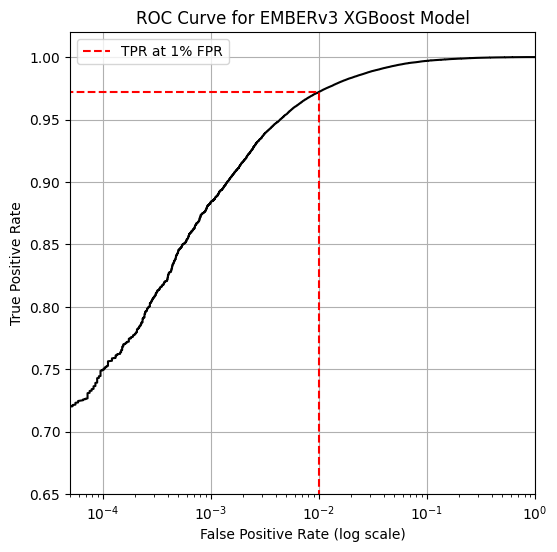

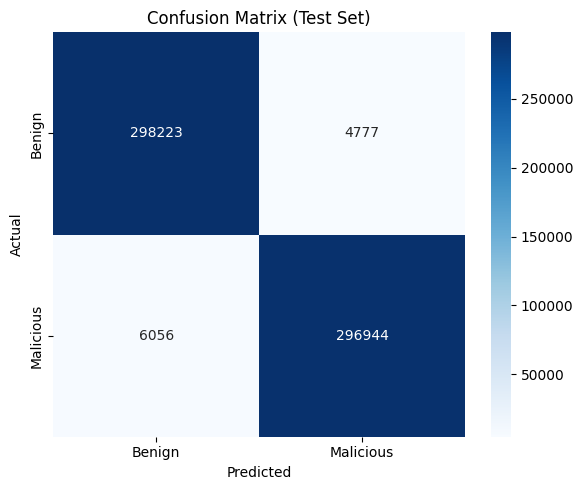

ROC AUC on test set: 0.998242717320742
PR AUC on test set: 0.998386439732097
Test accuracy at threshold 0.5: 0.9821237623762377
Confusion matrix on test set:
[[298223   4777]
 [  6056 296944]]
TN: 298223, FP: 4777, FN: 6056, TP: 296944
Number of incorrectly classified test samples: 10833
Saved ROC curve plot to /content/drive/MyDrive/EMBER2024/Fine-tunedV2/Classifier_ROC_AUC.png
Saved confusion matrix plot to /content/drive/MyDrive/EMBER2024/Fine-tunedV2/test_confusion_matrix.png
TPR of test set at FPR 0.01: 0.9720561056105611
Saved metrics log to /content/drive/MyDrive/EMBER2024/Fine-tunedV2/test_metrics_output.txt


In [18]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    accuracy_score,
    confusion_matrix,
)

OUTPUT_ROOT = Path("/content/drive/MyDrive/EMBER2024/Fine-tunedV2")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

y_score = model.predict_proba(X_test)[:, 1]

# Default threshold for binary classification
y_pred = (y_score >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_score)
precision, recall, _ = precision_recall_curve(y_test, y_score)
pr_auc = auc(recall, precision)

test_acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
num_incorrect = fp + fn

fpr, tpr, thresholds = roc_curve(y_test, y_score)

# ROC curve
plt.figure(figsize=(6, 6))
plt.title("ROC Curve for EMBERv3 XGBoost Model")
plt.plot(fpr, tpr, color="black")
plt.xlim(0.00005, 1.0)
plt.ylim(0.65, 1.02)
plt.xscale("log")

fpr_target = 0.01
tpr_at_target = np.interp(fpr_target, fpr, tpr)

plt.plot(
    [fpr_target, fpr_target, 0],
    [0, tpr_at_target, tpr_at_target],
    color="red",
    linestyle="--",
    label="TPR at 1% FPR"
)

plt.xlabel("False Positive Rate (log scale)")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()

plot_path = OUTPUT_ROOT / "Classifier_ROC_AUC.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close()

# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"],
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()

cm_plot_path = OUTPUT_ROOT / "test_confusion_matrix.png"
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

txt_path = OUTPUT_ROOT / "test_metrics_output.txt"

with open(txt_path, "w") as f:
    line = "ROC AUC on test set: {}".format(roc_auc)
    print(line)
    f.write(line + "\n")

    line = "PR AUC on test set: {}".format(pr_auc)
    print(line)
    f.write(line + "\n")

    line = "Test accuracy at threshold 0.5: {}".format(test_acc)
    print(line)
    f.write(line + "\n")

    line = "Confusion matrix on test set:\n{}".format(cm)
    print(line)
    f.write(line + "\n")

    line = "TN: {}, FP: {}, FN: {}, TP: {}".format(tn, fp, fn, tp)
    print(line)
    f.write(line + "\n")

    line = "Number of incorrectly classified test samples: {}".format(num_incorrect)
    print(line)
    f.write(line + "\n")

    line = f"Saved ROC curve plot to {plot_path}"
    print(line)

    line = f"Saved confusion matrix plot to {cm_plot_path}"
    print(line)

    line = "TPR of test set at FPR 0.01: {}".format(tpr_at_target)
    print(line)
    f.write(line + "\n")

print(f"Saved metrics log to {txt_path}")

In [19]:
# Load the challenge set
X_challenge, y_challenge = thrember.read_vectorized_features(data_dir, "challenge")

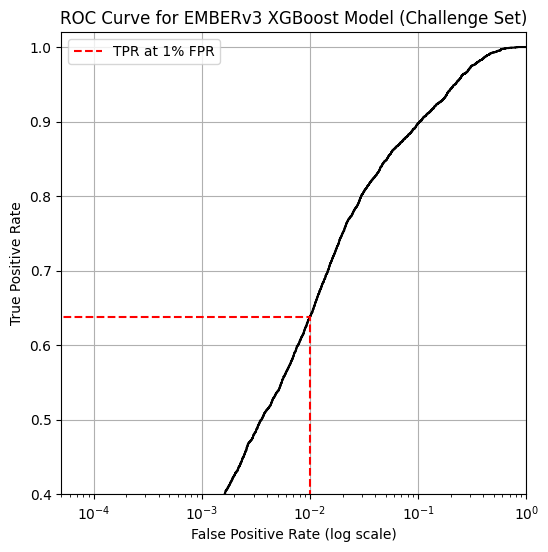

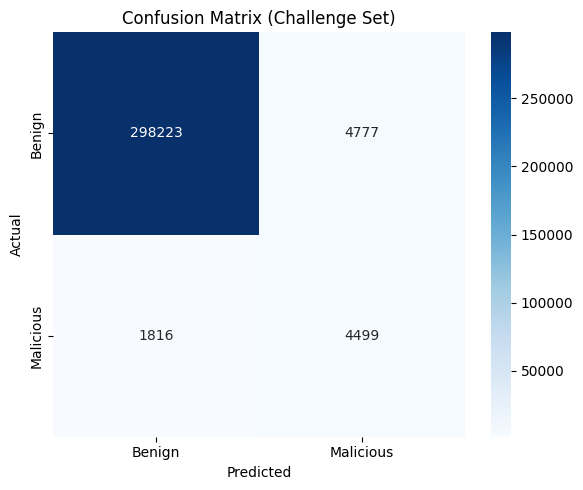

ROC AUC on challenge set: 0.9643690051190392
PR AUC on challenge set: 0.6641606804980422
Challenge accuracy at threshold 0.5: 0.978685159141975
Confusion matrix on challenge set:
[[298223   4777]
 [  1816   4499]]
TN: 298223, FP: 4777, FN: 1816, TP: 4499
Number of incorrectly classified challenge samples: 6593
Saved ROC curve plot to /content/drive/MyDrive/EMBER2024/Fine-tunedV2/Challenge_ROC_AUC.png
Saved confusion matrix plot to /content/drive/MyDrive/EMBER2024/Fine-tunedV2/challenge_confusion_matrix.png
TPR of challenge set at FPR 0.01: 0.6381631037212985
Saved metrics log to /content/drive/MyDrive/EMBER2024/Fine-tunedV2/challenge_metrics_output.txt


In [20]:
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    accuracy_score,
    confusion_matrix,
)

# Combine with benign files in test set
X_test_benign = X_test[y_test == 0]
y_test_benign = y_test[y_test == 0]
X_challenge = np.concatenate((X_test_benign, X_challenge), axis=0)
y_challenge = np.concatenate((y_test_benign, y_challenge), axis=0)

# Scores and default threshold predictions
y_score = model.predict_proba(X_challenge)[:, 1]
y_pred = (y_score >= 0.5).astype(int)

# Metrics
roc_auc = roc_auc_score(y_challenge, y_score)
precision, recall, _ = precision_recall_curve(y_challenge, y_score)
pr_auc = auc(recall, precision)

challenge_acc = accuracy_score(y_challenge, y_pred)
cm = confusion_matrix(y_challenge, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
num_incorrect = fp + fn

# ROC curve
fpr, tpr, thresholds = roc_curve(y_challenge, y_score)

plt.figure(figsize=(6, 6))
plt.title("ROC Curve for EMBERv3 XGBoost Model (Challenge Set)")
plt.plot(fpr, tpr, color="black")
plt.xlim(0.00005, 1.0)
plt.ylim(0.4, 1.02)
plt.xscale("log")

fpr_target = 0.01
tpr_at_target = np.interp(fpr_target, fpr, tpr)

plt.plot(
    [fpr_target, fpr_target, 0],
    [0, tpr_at_target, tpr_at_target],
    color="red",
    linestyle="--",
    label="TPR at 1% FPR",
)

plt.xlabel("False Positive Rate (log scale)")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()

challenge_plot_path = OUTPUT_ROOT / "Challenge_ROC_AUC.png"
plt.savefig(challenge_plot_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close()

# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"],
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Challenge Set)")
plt.tight_layout()

challenge_cm_plot_path = OUTPUT_ROOT / "challenge_confusion_matrix.png"
plt.savefig(challenge_cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

challenge_txt_path = OUTPUT_ROOT / "challenge_metrics_output.txt"

with open(challenge_txt_path, "w") as f:
    line = "ROC AUC on challenge set: {}".format(roc_auc)
    print(line)
    f.write(line + "\n")

    line = "PR AUC on challenge set: {}".format(pr_auc)
    print(line)
    f.write(line + "\n")

    line = "Challenge accuracy at threshold 0.5: {}".format(challenge_acc)
    print(line)
    f.write(line + "\n")

    line = "Confusion matrix on challenge set:\n{}".format(cm)
    print(line)
    f.write(line + "\n")

    line = "TN: {}, FP: {}, FN: {}, TP: {}".format(tn, fp, fn, tp)
    print(line)
    f.write(line + "\n")

    line = "Number of incorrectly classified challenge samples: {}".format(num_incorrect)
    print(line)
    f.write(line + "\n")

    line = f"Saved ROC curve plot to {challenge_plot_path}"
    print(line)

    line = f"Saved confusion matrix plot to {challenge_cm_plot_path}"
    print(line)

    line = "TPR of challenge set at FPR 0.01: {}".format(tpr_at_target)
    print(line)
    f.write(line + "\n")

print(f"Saved metrics log to {challenge_txt_path}")

In [ ]:
# Load the challenge set
X_train, y_train = thrember.read_vectorized_features(data_dir, "train")

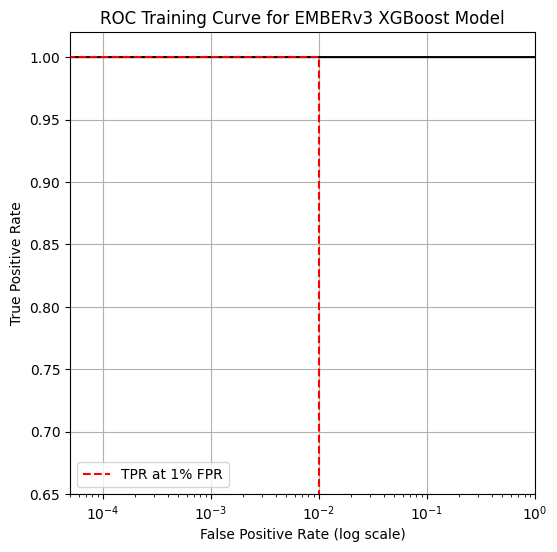

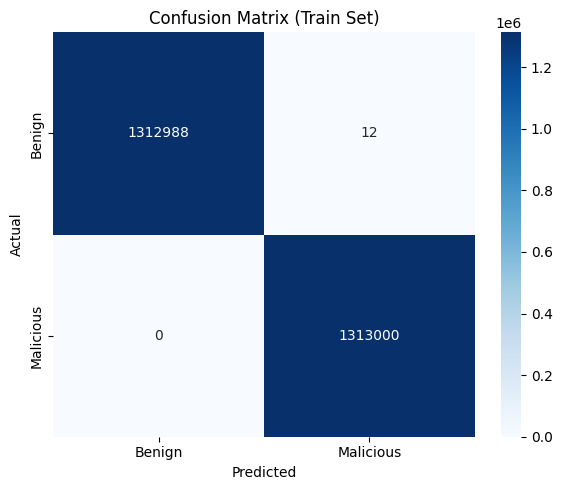

ROC AUC on train set: 0.9999999987885514
PR AUC on train set: 0.9999999987876623
Training accuracy at threshold 0.5: 0.999995430312262
Confusion matrix on train set:
[[1312988      12]
 [      0 1313000]]
TN: 1312988, FP: 12, FN: 0, TP: 1313000
Number of incorrectly classified training samples: 12
Saved ROC curve plot to /content/drive/MyDrive/EMBER2024/Fine-tunedV2/Classifier_train_ROC_AUC.png
Saved confusion matrix plot to /content/drive/MyDrive/EMBER2024/Fine-tunedV2/train_confusion_matrix.png
TPR of train set at FPR 0.01: 1.0
Saved metrics log to /content/drive/MyDrive/EMBER2024/Fine-tunedV2/train_metrics_output.txt


In [ ]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    accuracy_score,
    confusion_matrix,
)

OUTPUT_ROOT = Path("/content/drive/MyDrive/EMBER2024/Fine-tunedV2")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

y_score = model.predict_proba(X_train)[:, 1]

# Default threshold for binary classification
y_pred = (y_score >= 0.5).astype(int)

roc_auc = roc_auc_score(y_train, y_score)
precision, recall, _ = precision_recall_curve(y_train, y_score)
pr_auc = auc(recall, precision)

train_acc = accuracy_score(y_train, y_pred)
cm = confusion_matrix(y_train, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
num_incorrect = fp + fn

fpr, tpr, thresholds = roc_curve(y_train, y_score)

# ROC curve
plt.figure(figsize=(6, 6))
plt.title("ROC Training Curve for EMBERv3 XGBoost Model")
plt.plot(fpr, tpr, color="black")
plt.xlim(0.00005, 1.0)
plt.ylim(0.65, 1.02)
plt.xscale("log")

fpr_target = 0.01
tpr_at_target = np.interp(fpr_target, fpr, tpr)

plt.plot(
    [fpr_target, fpr_target, 0],
    [0, tpr_at_target, tpr_at_target],
    color="red",
    linestyle="--",
    label="TPR at 1% FPR"
)

plt.xlabel("False Positive Rate (log scale)")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()

plot_path = OUTPUT_ROOT / "Classifier_train_ROC_AUC.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close()

# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"],
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Train Set)")
plt.tight_layout()

cm_plot_path = OUTPUT_ROOT / "train_confusion_matrix.png"
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

txt_path = OUTPUT_ROOT / "train_metrics_output.txt"

with open(txt_path, "w") as f:
    line = "ROC AUC on train set: {}".format(roc_auc)
    print(line)
    f.write(line + "\n")

    line = "PR AUC on train set: {}".format(pr_auc)
    print(line)
    f.write(line + "\n")

    line = "Training accuracy at threshold 0.5: {}".format(train_acc)
    print(line)
    f.write(line + "\n")

    line = "Confusion matrix on train set:\n{}".format(cm)
    print(line)
    f.write(line + "\n")

    line = "TN: {}, FP: {}, FN: {}, TP: {}".format(tn, fp, fn, tp)
    print(line)
    f.write(line + "\n")

    line = "Number of incorrectly classified training samples: {}".format(num_incorrect)
    print(line)
    f.write(line + "\n")

    line = f"Saved ROC curve plot to {plot_path}"
    print(line)

    line = f"Saved confusion matrix plot to {cm_plot_path}"
    print(line)

    line = "TPR of train set at FPR 0.01: {}".format(tpr_at_target)
    print(line)
    f.write(line + "\n")

print(f"Saved metrics log to {txt_path}")